
Preemptive Priority Scheduler Results
PID  AT  BT  Priority  CT  TAT  WT
 P1   6   9         1  15    9   0
 P2   1   3         2   4    3   0
 P3   1  10         5  37   36  26
 P4   4   6         3  19   15   9
 P5   7   8         3  27   20  12

Average Waiting Time: 9.40
Average Turnaround Time: 16.60


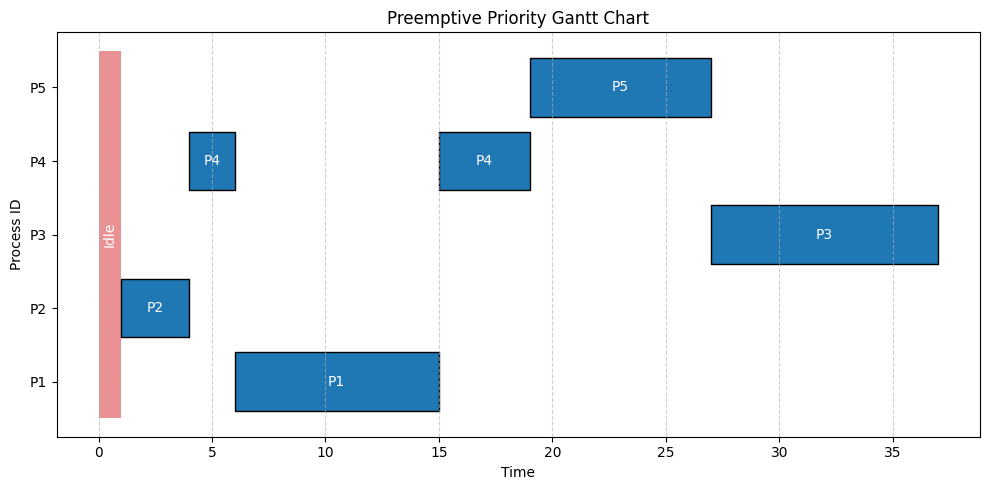

In [4]:
import random
import pandas as pd
import matplotlib.pyplot as plt

num_processes = int(input("Enter number of processes: "))

processes = []
for i in range(num_processes):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'RBT': 0,
        'Priority': random.randint(1, 5),
        'CT': 0,
        'WT': 0,
        'TAT': 0
    })

for p in processes:
    p['RBT'] = p['BT']

current_time = 0
completed = 0
n = len(processes)
timeline = []
last_pid = None

while completed < n:
    available = [p for p in processes if p['AT'] <= current_time and p['RBT'] > 0]

    if not available:
        if last_pid != 'Idle':
            timeline.append(('Idle', current_time, current_time + 1))
        else:
            timeline[-1] = ('Idle', timeline[-1][1], timeline[-1][2] + 1)

        last_pid = 'Idle'
        current_time += 1
        continue

    current = min(available, key=lambda x: (x['Priority'], x['AT']))

    if last_pid == current['PID']:
        timeline[-1] = (current['PID'], timeline[-1][1], timeline[-1][2] + 1)
    else:
        timeline.append((current['PID'], current_time, current_time + 1))

    last_pid = current['PID']

    current['RBT'] -= 1
    current_time += 1

    if current['RBT'] == 0:
        current['CT'] = current_time
        current['TAT'] = current['CT'] - current['AT']
        current['WT'] = current['TAT'] - current['BT']
        completed += 1

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("\nPreemptive Priority Scheduler Results")
print(df[['PID', 'AT', 'BT', 'Priority', 'CT', 'TAT', 'WT']].to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))

unique_pids = df['PID'].unique()
y_positions = {pid: i for i, pid in enumerate(unique_pids)}
mid_y = len(unique_pids) / 2 - 0.5

for label, start, end in timeline:
    duration = end - start
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)),
                       facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, mid_y, 'Idle',
                ha='center', va='center', color='white', rotation=90)
    else:
        y = y_positions[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white')

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title('Preemptive Priority Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Preemptive Priority Scheduler Results
PID  AT  BT  Priority  CT  TAT  WT
 P1   5  10         4  40   35  25
 P2   3   5         2  22   19  14
 P3   3   8         1  11    8   0
 P4   4   6         1  17   13   7
 P5   1  10         3  30   29  19
 P6   5   6         5  46   41  35

Average Waiting Time: 16.67
Average Turnaround Time: 24.17


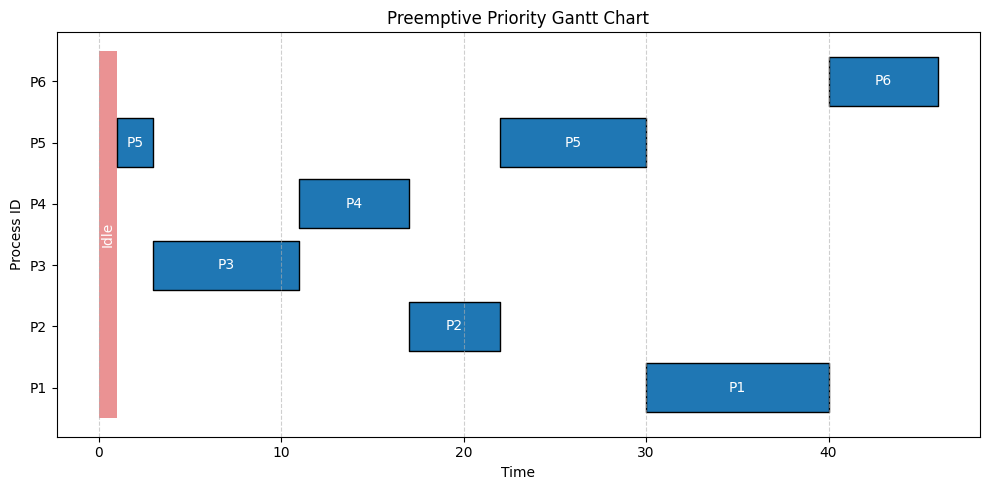

In [5]:
import random
import pandas as pd
import matplotlib.pyplot as plt

num_processes = int(input("Enter number of processes: "))

processes = []
for i in range(num_processes):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'RBT': 0,
        'Priority': random.randint(1, 5),
        'CT': 0,
        'WT': 0,
        'TAT': 0
    })

for p in processes:
    p['RBT'] = p['BT']

current_time = 0
completed = 0
n = len(processes)
timeline = []
last_pid = None

while completed < n:
    available = [p for p in processes if p['AT'] <= current_time and p['RBT'] > 0]

    if not available:
        if last_pid != 'Idle':
            timeline.append(('Idle', current_time, current_time + 1))
        else:
            timeline[-1] = ('Idle', timeline[-1][1], timeline[-1][2] + 1)

        last_pid = 'Idle'
        current_time += 1
        continue

    current = min(available, key=lambda x: (x['Priority'], x['AT']))

    if last_pid == current['PID']:
        timeline[-1] = (current['PID'], timeline[-1][1], timeline[-1][2] + 1)
    else:
        timeline.append((current['PID'], current_time, current_time + 1))

    last_pid = current['PID']

    current['RBT'] -= 1
    current_time += 1

    if current['RBT'] == 0:
        current['CT'] = current_time
        current['TAT'] = current['CT'] - current['AT']
        current['WT'] = current['TAT'] - current['BT']
        completed += 1

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("\nPreemptive Priority Scheduler Results")
print(df[['PID', 'AT', 'BT', 'Priority', 'CT', 'TAT', 'WT']].to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))

unique_pids = df['PID'].unique()
y_positions = {pid: i for i, pid in enumerate(unique_pids)}
mid_y = len(unique_pids) / 2 - 0.5

for label, start, end in timeline:
    duration = end - start
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)),
                       facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, mid_y, 'Idle',
                ha='center', va='center', color='white', rotation=90)
    else:
        y = y_positions[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white')

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title('Preemptive Priority Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
